In [6]:
import numpy as np
import pandas as pd
import h5py

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })


detections_narrow_ETT = pd.read_csv("./detection_output/narrow_ETT.dat", sep=" ")
detections_narrow_ETL = pd.read_csv("./detection_output/narrow_ETL.dat", sep=" ")
detections_narrow_ETT_CE = pd.read_csv("./detection_output/narrow_ETT_CE.dat", sep=" ")
detections_narrow_ETL_CE = pd.read_csv("./detection_output/narrow_ETL_CE.dat", sep=" ")
detections_wide_ETT = pd.read_csv("./detection_output/wide_ETT.dat", sep=" ")
detections_wide_ETL = pd.read_csv("./detection_output/wide_ETL.dat", sep=" ")
detections_wide_ETT_CE = pd.read_csv("./detection_output/wide_ETT_CE.dat", sep=" ")
detections_wide_ETL_CE = pd.read_csv("./detection_output/wide_ETL_CE.dat", sep=" ")

df_narrow_gw = pd.read_csv("../gw/gw_params_narrow.dat", sep=" ")
df_wide_gw = pd.read_csv("../gw/gw_params_wide.dat", sep=" ")

df_narrow_kn = pd.read_csv("../kilonova/kn_params_narrow.dat", sep=" ")
df_wide_kn = pd.read_csv("../kilonova/kn_params_wide.dat", sep=" ")

df_narrow_grb = pd.read_csv("../grb/grb_params_narrow.dat", sep=" ")
df_wide_grb = pd.read_csv("../grb/grb_params_wide.dat", sep=" ")

# Abstract

In [7]:
def total_mm(df):
    total = np.sum(np.any(df[["kn_visible", "grb_afg_visible", "kn_afg_visible"]], axis=1))
    return total
 
print("narrow mass model ET", total_mm(detections_narrow_ETT), total_mm(detections_narrow_ETL) )
print("wide mass model ET", total_mm(detections_wide_ETT), total_mm(detections_wide_ETL) )
print("narrow mass model ET+CE", total_mm(detections_narrow_ETT_CE), total_mm(detections_narrow_ETL_CE) )
print("wide mass model ET+CE", total_mm(detections_wide_ETT_CE), total_mm(detections_wide_ETL_CE) )


narrow mass model ET 78 112
wide mass model ET 74 101
narrow mass model ET+CE 312 592
wide mass model ET+CE 202 320


# Detection plot

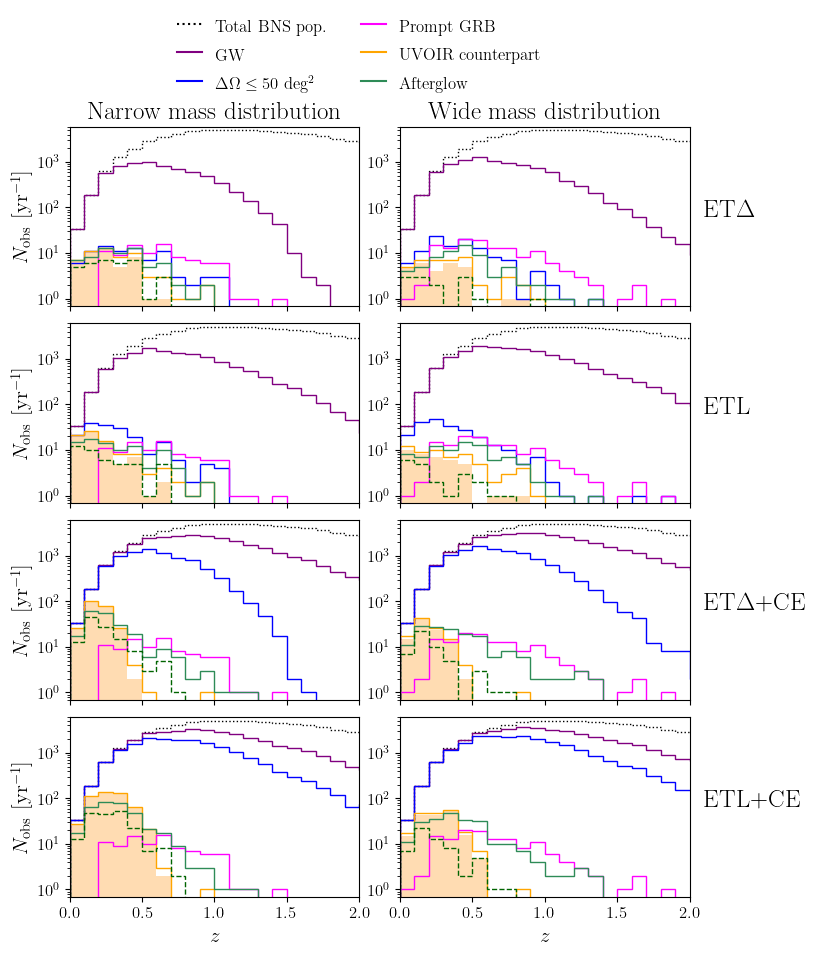

In [8]:
def plot_detections(ax, df):
    
    gw_detected = df["gw_detected"].astype(bool)
    grb_detected = df["grb_detected"].astype(bool)
    uvoir_detected = np.sum(df[["lsstg", "lssti", "ztfg", "ztfi", "ps1::i", "ps1::g", "f158", "f213", "ultrasat_custom"]], axis=1) >= 2
    sky_loc = (df["DeltaOmega"] <= 50.) & df["gw_detected"].astype(bool)
    afterglow_detected = np.sum(df[["radio_afterglow", "opt_afterglow", "xray_afterglow"]], axis=1) >= 1

    kn_visible = df["kn_visible"].astype(bool)
    grb_afg_visible = df["grb_afg_visible"].astype(bool)
    kn_afg_visible = df["kn_afg_visible"].astype(bool)

    bins = np.linspace(0, 3, 31)
    ax.hist(df["redshift"], bins=bins, histtype = "step", color="black", linestyle="dotted")
    ax.hist(df["redshift"][gw_detected], bins=bins, histtype="step", color="purple", label="GW detections")
    ax.hist(df["redshift"][sky_loc], bins=bins, histtype="step", color="blue", label="$\\Delta\\Omega \\leq 100$ deg$^2$")
    ax.hist(df["redshift"][uvoir_detected], bins=bins, histtype="step", color="orange", label="KN detections")
    ax.hist(df["redshift"][grb_detected], bins=bins, histtype="step", color="magenta", label="GRB detections")
    ax.hist(df["redshift"][afterglow_detected], bins=bins, histtype="step", color="seagreen", label="Afterglow detections")
    
    ax.hist(df["redshift"][kn_visible], bins=bins, alpha=0.3, color="darkorange", rasterized=True)
    #ax.hist(df["redshift"][kn_visible], bins=bins, histtype="step", linestyle="dashed", color="darkorange", rasterized=True)
    ax.hist(df["redshift"][kn_afg_visible], bins=bins, color="darkgreen", histtype="step", linestyle="dashed", rasterized=True)

    ax.set_yscale("log")
    ax.set_ylim((0.7, 6e3))
    ax.set_xlim((0, 2))


fig, ax = plt.subplots(4, 2, figsize= (8, 10), sharex=True)
fig.subplots_adjust(hspace=0.1, wspace=0.14)

ax[0,0].set_title("Narrow mass distribution", fontsize=18)
ax[0,0].set_ylabel("$N_{\\mathrm{obs}}$ [yr$^{-1}$]", fontsize=15)
plot_detections(ax[0,0], detections_narrow_ETT)
ax[0,1].set_title("Wide mass distribution", fontsize=18)
ax[0,1].text(1.05, 0.5, "ET$\\Delta$", rotation=0, transform=ax[0,1].transAxes, fontsize=18)
plot_detections(ax[0,1], detections_wide_ETT)


ax[1,0].set_ylabel("$N_{\\mathrm{obs}}$ [yr$^{-1}$]", fontsize=15)
plot_detections(ax[1,0], detections_narrow_ETL)
ax[1,1].text(1.05, 0.5, "ETL", rotation=0, transform=ax[1,1].transAxes, fontsize=18)
plot_detections(ax[1,1], detections_wide_ETL)


ax[2,0].set_ylabel("$N_{\\mathrm{obs}}$ [yr$^{-1}$]", fontsize=15)
plot_detections(ax[2,0], detections_narrow_ETT_CE)
ax[2,1].text(1.05, 0.5, "ET$\\Delta$+CE", rotation=0, transform=ax[2,1].transAxes, fontsize=18)
plot_detections(ax[2,1], detections_wide_ETT_CE)


ax[3,0].set_ylabel("$N_{\\mathrm{obs}}$ [yr$^{-1}$]", fontsize=15)
plot_detections(ax[3,0], detections_narrow_ETL_CE)
ax[3,1].text(1.05, 0.5, "ETL+CE", rotation=0, transform=ax[3,1].transAxes, fontsize=18)
plot_detections(ax[3,1], detections_wide_ETL_CE)
ax[3,0].set_xlabel("$z$", fontsize=15)
ax[3,1].set_xlabel("$z$", fontsize=15)



labels = [r"Total BNS pop.", r"GW", r"$\Delta\Omega\leq50$ deg$^2$", "Prompt GRB", "UVOIR counterpart", "Afterglow"]
lc1 = plt.plot([], [], color="purple")[0]
lc2 = plt.plot([], [], color="blue")[0]
lc3 = plt.plot([], [], color="magenta")[0]
lc4 = plt.plot([], [], color="orange")[0]
lc5 = plt.plot([], [], color="seagreen",)[0]
lc0 = plt.plot([], [], color="black", linestyle="dotted")[0]
ax[0,0].legend([lc0, lc1, lc2, lc3, lc4, lc5], 
                labels, 
                handlelength=1.5, handleheight=1.5,
                bbox_to_anchor=[1., 1.1],loc='lower center',frameon=False, ncol=2)

fig.savefig("../../figures/detections.pdf", dpi=250, bbox_inches="tight")

In [39]:
from fiesta.conversions import redshift_to_luminosity_distance
import jax.numpy as jnp

In [41]:
redshift_to_luminosity_distance(jnp.array([0.6]))

Array([3638.12382865], dtype=float64)

In [9]:
def afterglow_share(df):
    afterglow_detected = np.sum(df[["radio_afterglow", "opt_afterglow", "xray_afterglow"]], axis=1) >= 1


    print("GRB afgs:", np.sum(df["grb_afg_visible"].astype(bool)))
    print("KN afgs:", np.sum(df["kn_afg_visible"].astype(bool)))
    print("GRB & KN afgs:", np.sum(df["grb_afg_visible"].astype(bool) & df["kn_afg_visible"].astype(bool)))
    print("Total afgs:", np.sum(afterglow_detected))

    # These might not quite add up 
    # because the flux criterion used during the detection pipe line 
    # and to determine which transient is which is slightly different!

In [10]:
def table_row(key, as_type_bool=False):

    if as_type_bool:
        row = f"{np.sum(detections_narrow_ETT[key].astype(bool))} & {np.sum(detections_narrow_ETL[key].astype(bool))} & {np.sum(detections_narrow_ETT_CE[key].astype(bool))} & {np.sum(detections_narrow_ETL_CE[key].astype(bool))} & {np.sum(detections_wide_ETT[key].astype(bool))} & {np.sum(detections_wide_ETL[key].astype(bool))} & {np.sum(detections_wide_ETT_CE[key].astype(bool))} & {np.sum(detections_wide_ETL_CE[key].astype(bool))} \\\\ \n"
    else:
        row = f"{np.sum(detections_narrow_ETT[key])} & {np.sum(detections_narrow_ETL[key])} & {np.sum(detections_narrow_ETT_CE[key])} & {np.sum(detections_narrow_ETL_CE[key])} & {np.sum(detections_wide_ETT[key])} & {np.sum(detections_wide_ETL[key])} & {np.sum(detections_wide_ETT_CE[key])} & {np.sum(detections_wide_ETL_CE[key])} \\\\ \n"
    
    return row

def total_table_row(keys, min_threshold=1):

    row = f" "

    for df in [detections_narrow_ETT, detections_narrow_ETL, detections_narrow_ETT_CE, detections_narrow_ETL_CE, detections_wide_ETT, detections_wide_ETL, detections_wide_ETT_CE, detections_wide_ETL_CE]:
        row += f"& {np.sum(np.sum(df[keys], axis=1)>=min_threshold)} "
    
    row += " \\\\ \n"

    return row


def afterglow_row(key):
    
    row = f" "

    for df in [detections_narrow_ETT, detections_narrow_ETL, detections_narrow_ETT_CE, detections_narrow_ETL_CE, detections_wide_ETT, detections_wide_ETL, detections_wide_ETT_CE, detections_wide_ETL_CE]:
        row += f"& {np.sum(df[key].astype(bool))}~({np.sum(df[key].astype(bool) & df['afterglow_search'])}) "
    
    row += " \\\\ \n"
    
    return row

with open("table.tex", "w") as out:

    out.write("\\toprule \n\\toprule \n")
    out.write(" & Instrument & \\SetCell[c=4]{c} Narrow mass distribution& & & & \\SetCell[c=4]{c} Wide mass distribution & & &\\\\ \n")
    out.write(" & & ET$\\Delta$ & ETL & ET$\\Delta$+CE & ETL+CE & ET$\\Delta$ & ETL & ET$\\Delta$+CE & ETL+CE \\\\ \n ")
    out.write("\\midrule \n")
    
    # GRB
    out.write(f"\\SetCell[r=5]{{c}} GRB & Fermi/GBM & \\SetCell[c=4]{{c}} {np.sum(df_narrow_grb['fermi_detected'])} & & & & \\SetCell[c=4]{{c}} {np.sum(df_wide_grb['fermi_detected'])} & & & \\\\ \n")
    out.write(f" & Swift/BAT & \\SetCell[c=4]{{c}} {np.sum(df_narrow_grb['swift_detected'])} & & & & \\SetCell[c=4]{{c}} {np.sum(df_wide_grb['swift_detected'])} & & & \\\\ \n")
    out.write(f" & GECAM & \\SetCell[c=4]{{c}} {np.sum(df_narrow_grb['gecam_detected'])} & & & & \\SetCell[c=4]{{c}} {np.sum(df_wide_grb['gecam_detected'])} & & & \\\\ \n")
    out.write(f" & SVOM/ECLAIRs & \\SetCell[c=4]{{c}} {np.sum(df_narrow_grb['eclair_detected'])} & & & & \\SetCell[c=4]{{c}} {np.sum(df_wide_grb['eclair_detected'])} & & & \\\\ \n")
    out.write(f" & \\textbf{{Total}} & \\SetCell[c=4]{{c}} {np.sum(np.sum(df_narrow_grb[['swift_detected', 'fermi_detected', 'gecam_detected', 'eclair_detected']], axis=1)>=1)} & & & & \\SetCell[c=4]{{c}} {np.sum(np.sum(df_wide_grb[['swift_detected', 'fermi_detected', 'gecam_detected', 'eclair_detected']], axis=1)>=1)} & & & \\\\ \n")
    # GW 
    out.write(f"\\midrule \n")
    out.write(f" GW & - & {table_row('gw_detected')}")

    # UVOIR
    out.write(f"\\midrule \n")
    out.write(f"\\SetCell[r=10]{{c}} UVOIR search & Rubin $g$ & {table_row('lsstg', True)}")
    out.write(f" & Rubin $i$ & {table_row('lssti', True)}")
    out.write(f" & PSTARRS~$g$ & {table_row('ps1::g', True)}")
    out.write(f" & PSTARRS~$i$ & {table_row('ps1::i', True)}")
    out.write(f" & ZTF $g$ & {table_row('ztfg', True)}")
    out.write(f" & ZTF $i$ & {table_row('ztfi', True)}")
    out.write(f" & Roman F158 & {table_row('f158', True)}")
    out.write(f" & Roman F213 & {table_row('f158', True)}")
    out.write(f" & ULTRASAT & {table_row('ultrasat_custom', True)}")
    out.write(f" & \\textbf{{Total}} {total_table_row(['ztfg' , 'ztfi', 'ps1::g', 'ps1::i', 'lsstg', 'lssti', 'f158', 'f213', 'ultrasat_custom'], min_threshold=2)}")

    # Afterglow
    out.write(f"\\midrule \n")
    out.write(f"\\SetCell[r=4]{{c}} Afterglow search & radio {afterglow_row('radio_afterglow')}")
    out.write(f" & optical {afterglow_row('opt_afterglow')}")
    out.write(f" & X-ray {afterglow_row('xray_afterglow')}")
    out.write(f" & \\textbf{{Total}} {total_table_row(['radio_afterglow', 'opt_afterglow', 'xray_afterglow'], min_threshold=1)}")


    # Transient share
    out.write(f"\\midrule \n")
    out.write(f"\\SetCell[r=3]{{c}} \\textit{{Actual transient type}} & KN & {table_row('kn_visible', as_type_bool=True)}")
    out.write(f" & GRB afg. & {table_row('grb_afg_visible', as_type_bool=True)}")
    out.write(f" & KN afg. & {table_row('kn_afg_visible', as_type_bool=True)}")

    out.write("\\bottomrule \n")

In [11]:
def telescope_time_row(df):
    
    row = f" "
    for key in ["telt_vr", "telt_pstarrs", "telt_ztf", "telt_roman", "telt_ultrasat"]:
        if key in ["telt_ultrasat", "telt_roman"]:
            total = 3.65
        else: 
            total = 3.65*0.5
        row += f"& {np.sum(df[key])/total:.1f} "
    
    row += " \\\\ \n"

    return row

with open("table_telescopetime.tex", "w") as out:

    out.write("\\toprule \n\\toprule \n")
    out.write("& & Rubin & PAN\\-STARRS & ZTF & Roman & ULTRA\\-SAT \\\\ \n")
    out.write(f"\\midrule \n") 

    for detector, df in zip(["\\ett", "ETL", "\\ett+CE", "ETL+CE"], [detections_narrow_ETT, detections_narrow_ETL, detections_narrow_ETT_CE, detections_narrow_ETL_CE]):
        if detector=="\\ett":
            out.write(f"\\SetCell[r=4]{{c}} \\rotatebox{{{90}}}{{Narrow}} & {detector} {telescope_time_row(df)}")
        else:
            out.write(f" & {detector} {telescope_time_row(df)}")

    out.write(f"\\midrule \n ")

    for detector, df in zip(["\\ett", "ETL", "\\ett+CE", "ETL+CE"], [detections_wide_ETT, detections_wide_ETL, detections_wide_ETT_CE, detections_wide_ETL_CE]):
        if detector=="\\ett":
            out.write(f"\\SetCell[r=4]{{c}} \\rotatebox{{{90}}}{{Wide}} & {detector} {telescope_time_row(df)}")
        else:
            out.write(f" & {detector} {telescope_time_row(df)}")


    out.write("\\bottomrule \n")

# GW DeltaOmega

In [16]:
df_fim_narrow_ETL_CE = pd.read_csv("./outdir_FIM/gwfish_narrow_ETL_CE.dat", sep=" ")
df_fim_narrow_ETT_CE = pd.read_csv("./outdir_FIM/gwfish_narrow_ETT_CE.dat", sep=" ")
df_fim_wide_ETL_CE = pd.read_csv("./outdir_FIM/gwfish_wide_ETL_CE.dat", sep=" ")
df_fim_wide_ETT_CE = pd.read_csv("./outdir_FIM/gwfish_wide_ETT_CE.dat", sep=" ")

df_fim_narrow_ETL = pd.read_csv("./outdir_FIM/gwfish_narrow_ETL.dat", sep=" ")
df_fim_narrow_ETT = pd.read_csv("./outdir_FIM/gwfish_narrow_ETT.dat", sep=" ")
df_fim_wide_ETL = pd.read_csv("./outdir_FIM/gwfish_wide_ETL.dat", sep=" ")
df_fim_wide_ETT = pd.read_csv("./outdir_FIM/gwfish_wide_ETT.dat", sep=" ")

def print_DeltaOmega_quantiles(fim_df, detection_df):
    mask = detection_df["gw_detected"].astype(bool)

    print(np.quantile(fim_df["sky_localization"][mask], q=[0.1, 0.5]))

def print_DeltaOmega_shares(fim_df, detection_df, cutoff):
    mask = detection_df["gw_detected"].astype(bool)   
    print(np.sum(fim_df["sky_localization"][mask]<cutoff) / np.sum(mask))


print_DeltaOmega_quantiles(df_fim_narrow_ETT_CE, detections_narrow_ETT_CE)
print_DeltaOmega_quantiles(df_fim_wide_ETT_CE, detections_wide_ETT_CE)


print_DeltaOmega_quantiles(df_fim_narrow_ETL_CE, detections_narrow_ETL_CE)
print_DeltaOmega_quantiles(df_fim_wide_ETL_CE, detections_wide_ETL_CE)

[24.18102696 85.08877342]
[21.48583036 78.76678396]
[13.80159869 49.10669358]
[12.28810212 45.91726535]


In [31]:
print(np.sum(df_fim_wide_ETL["sky_localization"] <= 100))
print(np.sum(df_fim_wide_ETT["sky_localization"] <= 100))

372
74


In [28]:
print_DeltaOmega_shares(df_fim_narrow_ETT, detections_narrow_ETT, 22)
print_DeltaOmega_shares(df_fim_wide_ETT, detections_wide_ETT, 22)
print_DeltaOmega_shares(df_fim_narrow_ETT, detections_narrow_ETT, 80)
print_DeltaOmega_shares(df_fim_wide_ETT, detections_wide_ETT, 80)

0.001002290950744559
0.0008371703641691084
0.006872852233676976
0.005232314776056928


In [29]:
print_DeltaOmega_shares(df_fim_narrow_ETL, detections_narrow_ETL, 13)
print_DeltaOmega_shares(df_fim_wide_ETL, detections_wide_ETL, 13)
print_DeltaOmega_shares(df_fim_narrow_ETL, detections_narrow_ETL, 48)
print_DeltaOmega_shares(df_fim_wide_ETL, detections_wide_ETL, 48)

0.0014682131845543973
0.0010744783125035346
0.008075172515049186
0.006616524345416501


In [8]:
def print_DeltaOmega_quantiles(fim_df, detection_df):
    mask = detection_df["gw_detected"].astype(bool)

    print(np.quantile(fim_df["DeltaOmega"][mask], q=[0.5, 0.9]))

print_DeltaOmega_quantiles(detections_narrow_ETL_CE)
print_DeltaOmega_quantiles(detections_wide_ET_CE)

print(np.sum(detections_narrow_ETL["DeltaOmega"]<=50.31)/ np.sum(detections_narrow_ETL["gw_detected"]), np.sum(detections_narrow_ETL["DeltaOmega"]<=127.915)/ np.sum(detections_narrow_ETL["gw_detected"])) 
print(np.sum(detections_wide_ETL["DeltaOmega"]<=48.56)/ np.sum(detections_wide_ETL["gw_detected"]), np.sum(detections_wide_ETL["DeltaOmega"]<=126.982)/np.sum(detections_wide_ETL["gw_detected"])) 

TypeError: print_DeltaOmega_quantiles() missing 1 required positional argument: 'detection_df'

## Vera Rubin dominance

In [30]:
def vr_relevance(df):
    detection_no_vr = (np.sum(df[["lsstg", "lssti", "ztfg", "ztfi", "ps1::i", "ps1::g", "ultrasat_custom"]], axis=1) >= 2) & (np.sum(df[["lsstg", "lssti"]], axis=1) ==0)

    one_time_detections_vr = (np.sum(df[["lsstg", "lssti"]], axis=1)==1)

    return np.sum(detection_no_vr), np.sum(one_time_detections_vr), np.sum(df.loc[one_time_detections_vr, ["lsstg", "lssti"]], axis=0)

In [34]:
for df in [detections_narrow_ETT, 
           detections_narrow_ETL, 
           detections_narrow_ETT_CE, 
           detections_narrow_ETL_CE, 
           detections_wide_ETT, 
           detections_wide_ETL, 
           detections_wide_ETT_CE, 
           detections_wide_ETL_CE]:
    
    print(vr_relevance(df)[2])

lsstg    4
lssti    3
dtype: int64
lsstg    4
lssti    4
dtype: int64
lsstg     7
lssti    11
dtype: int64
lsstg    40
lssti    28
dtype: int64
lsstg    8
lssti    2
dtype: int64
lsstg    9
lssti    3
dtype: int64
lsstg    11
lssti    10
dtype: int64
lsstg    37
lssti    18
dtype: int64


### KN afterglows without KN

In [44]:
for df in [detections_narrow_ETT, 
           detections_narrow_ETL, 
           detections_narrow_ETT_CE, 
           detections_narrow_ETL_CE, 
           detections_wide_ETT, 
           detections_wide_ETL, 
           detections_wide_ETT_CE, 
           detections_wide_ETL_CE]:
    
    uvoir_detected = np.sum(df[["lsstg", "lssti", "ztfg", "ztfi", "ps1::i", "ps1::g", "f158", "f213", "ultrasat_custom"]], axis=1) >= 2

    kn_afg_without_kn_with_grb_afg = np.sum(df["kn_afg_visible"].astype(bool) & ~df["kn_visible"].astype(bool) & df["grb_afg_visible"].astype(bool))/ np.sum(df["kn_afg_visible"].astype(bool))
    kn_afg_with_kn = np.sum(df["kn_afg_visible"].astype(bool) & df["kn_visible"].astype(bool))/ np.sum(df["kn_afg_visible"].astype(bool))
    print(kn_afg_without_kn_with_grb_afg,  
          kn_afg_with_kn,
          1 - kn_afg_with_kn - kn_afg_without_kn_with_grb_afg)

0.2857142857142857 0.7142857142857143 0.0
0.2727272727272727 0.7272727272727273 0.0
0.2288135593220339 0.7711864406779662 -5.551115123125783e-17
0.14646464646464646 0.8535353535353535 5.551115123125783e-17
0.3076923076923077 0.6923076923076923 0.0
0.3333333333333333 0.6666666666666666 5.551115123125783e-17
0.3469387755102041 0.6530612244897959 5.551115123125783e-17
0.3220338983050847 0.6779661016949152 5.551115123125783e-17


In [42]:
def kn_afterglow_peak_time(df, mass_dist):

    inds = np.where(df["kn_afg_visible"].astype(bool))
    file = f"../kilonova_afterglow/kilonova_afterglow_files/kn_afterglow_results_{mass_dist}.mat"

    with h5py.File(file) as f:
        flux = f["flux_mJy"][0, :, :]
        flux = flux[:, inds]
        times = f["t_days"][:].flatten()
    
    peak_inds = np.argmax(flux, axis=0)

    t_peak = times[peak_inds[0]]
    t_peak *= (1+df.loc[inds, "redshift"]).to_numpy()

    return np.quantile(t_peak, [0.025, 0.5, 0.975])


print(kn_afterglow_peak_time(detections_narrow_ETT, "narrow"))
print(kn_afterglow_peak_time(detections_narrow_ETL, "narrow"))
print(kn_afterglow_peak_time(detections_narrow_ETT_CE, "narrow"))
print(kn_afterglow_peak_time(detections_narrow_ETL_CE, "narrow"))
print("\n \n")
print(kn_afterglow_peak_time(detections_wide_ETT, "wide"))
print(kn_afterglow_peak_time(detections_wide_ETL, "wide"))
print(kn_afterglow_peak_time(detections_wide_ETT_CE, "wide"))
print(kn_afterglow_peak_time(detections_wide_ETL_CE, "wide"))


[  545.81940533  3444.27875001 11027.10142298]
[  592.28791708  2753.29754465 10711.97333148]
[  566.21121223  2307.94639728 10017.13494946]
[ 520.77874649 2264.55282789 9290.4370224 ]

 

[ 170.12594332 1880.99486913 6711.98176977]
[ 174.08120407 1910.6031217  6589.8772109 ]
[ 156.47001686 1201.26306067 6297.62814457]
[ 158.88346541 1310.56775074 6241.60537768]


## GRB afterglows without GRB

In [45]:
for df in [detections_narrow_ETT, 
           detections_narrow_ETL, 
           detections_narrow_ETT_CE, 
           detections_narrow_ETL_CE, 
           detections_wide_ETT, 
           detections_wide_ETL, 
           detections_wide_ETT_CE, 
           detections_wide_ETL_CE]:
    
    print(np.sum(df["grb_afg_visible"].astype(bool) & df["grb_detected"].astype(bool)) / np.sum(df["grb_detected"].astype(bool)))

0.46153846153846156
0.4725274725274725
0.5604395604395604
0.5824175824175825
0.41044776119402987
0.5
0.5223880597014925
0.5522388059701493


In [46]:
for df in [detections_narrow_ETT, 
           detections_narrow_ETL, 
           detections_narrow_ETT_CE, 
           detections_narrow_ETL_CE, 
           detections_wide_ETT, 
           detections_wide_ETL, 
           detections_wide_ETT_CE, 
           detections_wide_ETL_CE]:
    
    print(np.sum( (df["grb_detected"].astype(bool))  & df["grb_afg_visible"].astype(bool)) / 
          np.sum(df["grb_afg_visible"].astype(bool)))

0.7924528301886793
0.6515151515151515
0.3893129770992366
0.2663316582914573
0.859375
0.8072289156626506
0.5147058823529411
0.37


## GRBs without GW

In [47]:
for df in [detections_narrow_ETT, 
           detections_narrow_ETL, 
           detections_narrow_ETT_CE, 
           detections_narrow_ETL_CE, 
           detections_wide_ETT, 
           detections_wide_ETL, 
           detections_wide_ETT_CE, 
           detections_wide_ETL_CE]:
    
    print(np.sum(df["grb_detected"].astype(bool) & df["gw_detected"].astype(bool)) / 
          np.sum(df["grb_detected"].astype(bool)))

0.7362637362637363
0.8571428571428571
1.0
1.0
0.6865671641791045
0.8582089552238806
1.0
1.0


## Heavy BNS can be detected at high redshift

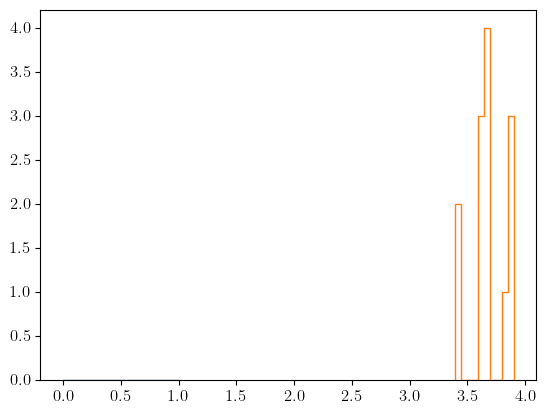

In [16]:
def plot_chirp_mass(df, detections):

    mask = detections["gw_detected"].astype(bool) & (df["redshift"] > 2)

    df["chirp_mass"] = (df["mass_1_source"] * df["mass_2_source"])**0.6/ (df["mass_1_source"]+ df["mass_2_source"])**0.2
    df["total_mass"] = df["mass_1_source"] + df["mass_2_source"]

    plt.hist(df.loc[mask, "total_mass"], histtype="step")

plot_chirp_mass(df_narrow_gw, detections_narrow_ETT)
plot_chirp_mass(df_wide_gw, detections_wide_ETT)